# Magneto-optics: the Kerr effect and the Hall conductivity

Shine linearly polarized light on a magnet and it comes back **rotated**. The angle is a
fraction of a degree, and it is the basis of every magneto-optical measurement of a thin
film. What produces it is the off-diagonal part of the optical conductivity tensor,

$$ \sigma_{ij}(\omega) \;=\; \frac{i}{\Omega}\sum_{\mathbf{k}}\sum_{n,m}
   \frac{W_n\,(1-f_m)}{\epsilon_{mn}}
   \left[\frac{v^i_{nm} v^j_{mn}}{\omega - \epsilon_{mn} + i\eta}
       + \frac{\overline{v^i_{nm} v^j_{mn}}}{\omega + \epsilon_{mn} + i\eta}\right] $$

a sum over pairs of bands weighted by how strongly light couples them. The diagonal part
$\sigma_{xx}$ is ordinary absorption. The **antisymmetric** part $\sigma_{xy}$ is the one
that rotates the polarization, and it is zero in almost every crystal: time reversal forbids
it outright, so a nonmagnetic solid has none no matter how heavy its atoms. A magnet whose
moments all point one way does not have it either, unless spin-orbit coupling is there to
tell the orbital motion which way the spin points.

So $\sigma_{xy}$ needs two things at once, and fcc nickel is the textbook case that has both.
Its static limit is the **anomalous Hall conductivity**: a current that flows sideways with
no magnetic field applied at all.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.system.kpoints import KPoints

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

nickel = Calculator.from_file(CASES / "ni-soc-nosym.in", pseudo_dir=PSEUDO,
                              announce=False)
ground = nickel.get_scf()

print(f"fcc Ni with spin-orbit coupling: moment "
      f"{ground.magnetization_vector[2]:.4f} mu_B along z, experiment 0.61")

fcc Ni with spin-orbit coupling: moment 0.6170 mu_B along z, experiment 0.61


## 1. The tensor

One call. It runs a fixed-density diagonalisation with empty states, builds the velocity
matrix elements between every pair of bands, and sums the expression above over a frequency
grid. The conductivity comes back in atomic units and in S/cm, the dielectric function
follows from it, and so does the Kerr angle.

The Brillouin-zone grid matters more here than it does for a total energy, because what is
being integrated is a difference of two nearly equal band energies. This one is deliberately
modest so the notebook runs in a few minutes.

In [2]:
mesh = KPoints.automatic((4, 4, 4), (0, 0, 0), nickel.system.cell,
                         precision=nickel.system.cell.precision)

sigma = nickel.get_optical_conductivity(kpoints=mesh, nbnd=36,
                                        window=0.6, nw=200, broadening=0.01)

ev = sigma.frequencies_ev
s = sigma.sigma_s_per_cm
at1 = int(np.argmin(abs(ev - 1.0)))
diagonal, offdiagonal = s[at1, 0, 0].real, s[at1, 0, 1].real

print(f"{mesh.nk} k-points, {sigma.nbnd} bands, "
      f"{len(ev)} frequencies up to {ev[-1]:.1f} eV")
print(f"at 1 eV:  sigma_xx {diagonal:12.1f} S/cm")
print(f"          sigma_xy {offdiagonal:12.1f} S/cm")
print(f"          ratio    {abs(offdiagonal / diagonal):12.2e}")

64 k-points, 36 bands, 200 frequencies up to 8.2 eV
at 1 eV:  sigma_xx       2917.8 S/cm
          sigma_xy       -139.5 S/cm
          ratio        4.78e-02


## 2. The two halves of the tensor

$\sigma_{xx}$ on the left is what any metal has: a Drude peak at zero frequency from carriers
at the Fermi surface, and interband structure above it. $\sigma_{xy}$ on the right is orders
of magnitude smaller, and exists only because the magnetization and the spin-orbit coupling
are both present. The ratio the cell above printed is why a Kerr angle is measured in
fractions of a degree rather than in degrees.

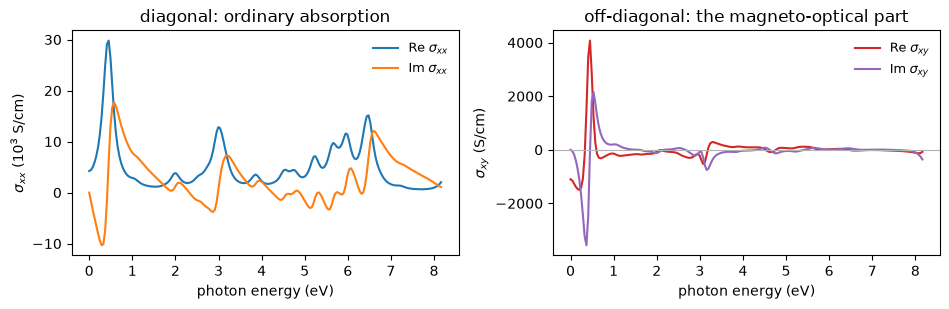

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))

axes[0].plot(ev, s[:, 0, 0].real / 1e3, label=r"Re $\sigma_{xx}$")
axes[0].plot(ev, s[:, 0, 0].imag / 1e3, label=r"Im $\sigma_{xx}$")
axes[0].set(xlabel="photon energy (eV)", ylabel=r"$\sigma_{xx}$ ($10^3$ S/cm)",
            title="diagonal: ordinary absorption")

antisym = 0.5 * (s[:, 0, 1] - s[:, 1, 0])
axes[1].plot(ev, antisym.real, color="C3", label=r"Re $\sigma_{xy}$")
axes[1].plot(ev, antisym.imag, color="C4", label=r"Im $\sigma_{xy}$")
axes[1].axhline(0.0, color="0.7", lw=0.8)
axes[1].set(xlabel="photon energy (eV)", ylabel=r"$\sigma_{xy}$ (S/cm)",
            title="off-diagonal: the magneto-optical part")

for ax in axes:
    ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

## 3. The Kerr angle

The measured quantity is the complex angle through which the reflected polarization turns,

$$ \theta_K + i\,\eta_K \;=\; \frac{-\sigma_{xy}}
   {\sigma_{xx}\sqrt{1 + 4\pi i \sigma_{xx}/\omega}} $$

with the real part the rotation and the imaginary part the ellipticity the reflected light
acquires. Nothing new is computed here: it is the tensor above, rearranged.

Two things about that expression are worth noticing before reading the figure. It divides by
$\sigma_{xx}$, so it **diverges** wherever the diagonal conductivity passes through zero,
which is why the angle is quoted in the visible rather than wherever it happens to be
largest.

And the **mesh** is what limits this figure, not the method. What is being integrated is a
small difference between large numbers, concentrated where two bands nearly touch at the
Fermi level, and sixty-four k-points do not resolve it: the curve below comes out a few
times larger than the measured tenth of a degree and wanders in sign, and refining the mesh
moves it substantially. A published magneto-optical spectrum uses a mesh two orders of
magnitude denser than this one. That is a property of the quantity rather than of this
calculation, and it is why the static limit is not quoted as a number at all.

through the visible (1.5 to 3.5 eV)
  root mean square rotation  0.661 deg
  largest                    +1.034 deg at 1.85 eV
  measured for bulk nickel   about 0.1 deg


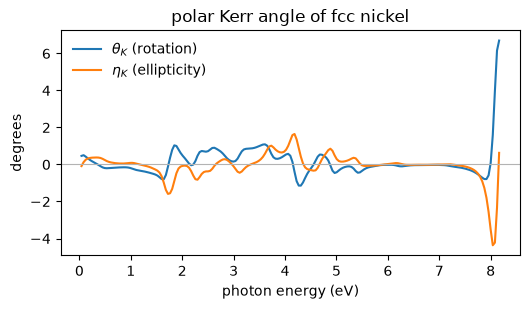

In [4]:
kerr = sigma.kerr

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(ev[1:], kerr.real[1:], label=r"$\theta_K$ (rotation)")
ax.plot(ev[1:], kerr.imag[1:], label=r"$\eta_K$ (ellipticity)")
ax.axhline(0.0, color="0.7", lw=0.8)
ax.set(xlabel="photon energy (eV)", ylabel="degrees",
       title="polar Kerr angle of fcc nickel")
ax.legend(frameon=False)
fig.tight_layout()

visible = (ev > 1.5) & (ev < 3.5)
peak = int(np.argmax(np.abs(np.where(visible, kerr.real, 0.0))))
typical = float(np.sqrt(np.mean(kerr.real[visible] ** 2)))

print(f"through the visible (1.5 to 3.5 eV)")
print(f"  root mean square rotation  {typical:.3f} deg")
print(f"  largest                    {kerr.real[peak]:+.3f} deg at {ev[peak]:.2f} eV")
print(f"  measured for bulk nickel   about 0.1 deg")

## 4. Why both ingredients are needed

Take the same expression to a crystal that has neither. Silicon is nonmagnetic, and time
reversal alone is enough: every contribution to $\sigma_{xy}$ from a state at $\mathbf{k}$ is
cancelled by its partner at $-\mathbf{k}$. Nothing in the calculation imposes this. The grid
is the full Brillouin zone with no symmetry applied, and the cancellation happens in the
arithmetic.

In [5]:
silicon = Calculator.from_file(CASES / "si2-nosym.in", pseudo_dir=PSEUDO,
                              announce=False)
si = silicon.get_optical_conductivity(nbnd=20, frequencies=[0.0], broadening=0.01)

si_anti = np.abs(0.5 * (si.sigma_s_per_cm[0] - si.sigma_s_per_cm[0].T)).max()
ni_anti = np.abs(sigma.hall_conductivity).max()

print(f"largest antisymmetric component, S/cm")
print(f"  nickel   (magnetic, spin-orbit)   {ni_anti:12.2f}")
print(f"  silicon  (neither)                {si_anti:12.2e}")

largest antisymmetric component, S/cm
  nickel   (magnetic, spin-orbit)        1101.90
  silicon  (neither)                    6.62e-08


## 5. The other half of a metal's conductivity

Everything above is interband: light promoting an electron from a filled band to an empty
one. A metal also conducts without any interband transition at all, because carriers sit
right at the Fermi level. That is the Drude term, and its strength is the plasma frequency

$$ \omega_{p,ab}^2 \;=\; \frac{4\pi}{\Omega}\sum_{\mathbf{k}}w_{\mathbf{k}}\sum_n
   v^a_{nn}\,v^b_{nn}\,\delta(\epsilon_n - E_F) $$

a Fermi-surface average of the band velocity. Aluminium is the metal this is worth doing on,
because it is as close to a free-electron gas as a real solid gets, and a free-electron gas
has $\hbar\omega_p = \sqrt{4\pi n}$ with nothing else in it.

In [6]:
aluminium = Calculator.from_file(CASES / "al-conductivity.in", pseudo_dir=PSEUDO,
                                announce=False)
al = aluminium.get_optical_conductivity(nbnd=12, window=1.2, nw=200)

volume = aluminium.system.cell.volume
density = aluminium.calculation.nelec / volume
free = np.sqrt(4 * np.pi * density) * 27.2113845

print(f"fcc aluminium, {aluminium.system.kpoints.nk} k-points")
print(f"  free-electron gas        {free:6.2f} eV")
print(f"  from the band structure  {al.plasma_ev[0, 0]:6.2f} eV")
print()
print(f"  isotropic to {np.abs(al.plasma_ev - np.diag(np.diag(al.plasma_ev))).max():.1e} eV"
      f"  (nothing imposes it: the run is nosym)")

fcc aluminium, 512 k-points
  free-electron gas         16.27 eV
  from the band structure   11.89 eV

  isotropic to 2.5e-04 eV  (nothing imposes it: the run is nosym)


The band structure takes about a quarter off the free-electron answer. That is the
zone-boundary gaps removing Fermi surface, and it is exactly the sense in which aluminium is
*nearly* free-electron rather than free-electron. (The bulk plasmon aluminium actually shows
in an energy-loss experiment, near 15 eV, is a different quantity: it is where the whole
dielectric function crosses zero, interband screening included, not the Drude weight alone.)

## What to read before believing a number

Two diagnostics come back with the tensor and both are worth looking at.

`fsum` is the spectral weight $\int_0^\infty \mathrm{Re}\,\sigma_{xx}\,d\omega$ divided by
$\pi n_e/2$. It is not one, and it is not supposed to be: that normalization assumes the
electrons move in a local potential, and a pseudopotential is not local. What it does
converge to is the crystal's own diamagnetic weight, and how far it is from converging is a
statement about the k-grid rather than about the band count.

`band_cut_gap` is the gap between the last band summed and the first one left out. When the
sum stops in the middle of a degenerate set of bands it keeps some members and drops others,
and cancellations that those members were making between them stop happening. On silicon that
is the difference between an antisymmetric conductivity of $4\times10^{-13}$ and one of
$10^{-5}$, in a quantity that is exactly zero.

The anomalous Hall conductivity of a **metal** deserves the same caution and more: its
integrand lives on near-degeneracies at the Fermi surface, so it converges far more slowly in
the k-grid than the spectrum at finite frequency does. The Kerr angle above is on much firmer
ground than the number at $\omega = 0$.

---

*Refused, with the reason in each case: ultrasoft and PAW datasets, a spin spiral, a
symmetry-reduced k-set, and collinear `nspin = 2`. The validation lives in
`tests/regression/test_conductivity.py` and `tests/unit/test_conductivity_machinery.py`.*